# Fase 1 — EDA y Diagnóstico Estocástico
## DR-COPPER | Análisis de la Dinámica Estocástica del Cobre (HG=F)
**Asignatura:** Modelos de Regresión y Series de Tiempo  
**Institución:** Universidad Tecnológica de Bolívar  
**Autor:** Alejandro Patron Montero  

---
### Objetivo de la Fase
Caracterizar estadísticamente la serie de precios del cobre (futuros HG=F, COMEX) para:
1. Detectar tendencia, estacionalidad y ruido mediante descomposición STL.
2. Validar la existencia de raíz unitaria (no estacionariedad) con las pruebas ADF y KPSS.
3. Confirmar que d=1 es suficiente para estacionarizar la serie.
4. Detectar heterocedasticidad condicional (efectos ARCH), que justifica GARCH en la Fase 4.

In [1]:
# ── Librerías ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats as sp_stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch

os.makedirs('output', exist_ok=True)
os.makedirs('data', exist_ok=True)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (13, 5)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Extracción de Datos
Descargamos el precio de cierre del futuro HG=F (COMEX, USD/libra) desde 1990 via `yfinance`.

In [2]:
# ── Descarga y limpieza ─────────────────────────────────────────────────────────
ticker = 'HG=F'
raw = yf.download(ticker, start='1990-01-01', end='2026-05-01',
                  auto_adjust=True, progress=False)

# yfinance >= 0.2 retorna MultiIndex columns cuando se pasa un solo ticker;
# .squeeze() colapsa el DataFrame de una columna a Serie.
df = raw['Close'].squeeze().dropna()
df.name = 'HG=F'
df.index = pd.to_datetime(df.index)

print(f'Registros descargados : {len(df):,}')
print(f'Periodo              : {df.index[0].date()} → {df.index[-1].date()}')
print(f'Último precio        : ${float(df.iloc[-1]):.4f} USD/lb')
df.tail(3)

Registros descargados : 6,445
Periodo              : 2000-08-30 → 2026-04-30
Último precio        : $5.9260 USD/lb


Date
2026-04-28    5.9145
2026-04-29    5.8785
2026-04-30    5.9260
Name: HG=F, dtype: float64

## 2. Visualización de la Serie Original
Evolución histórica con anotaciones de eventos macro clave.

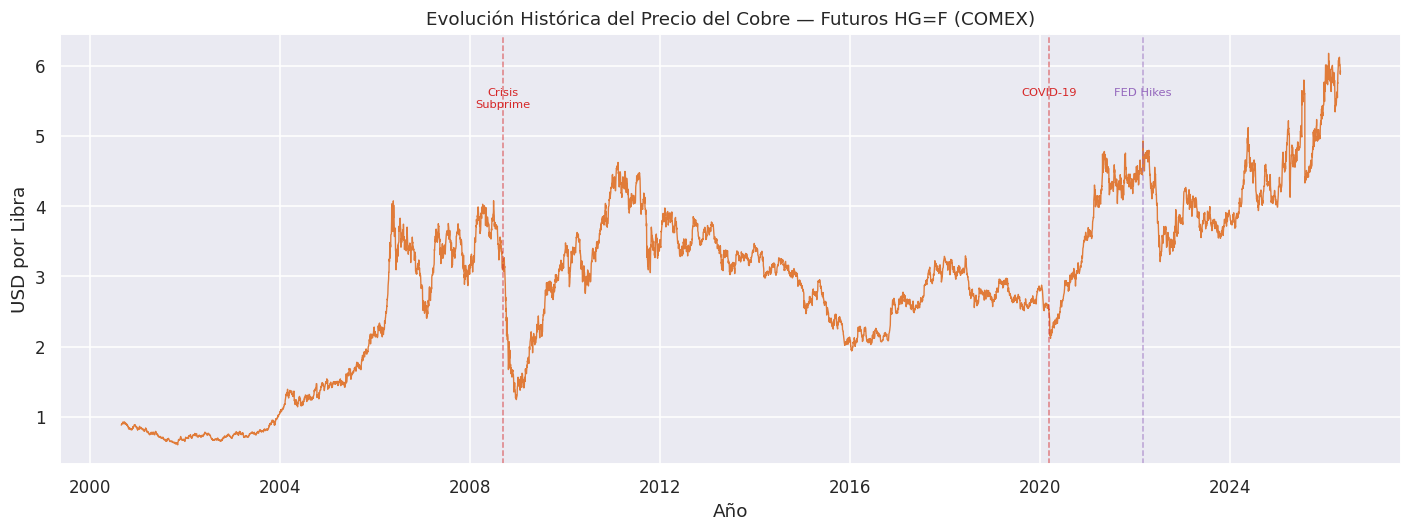

In [3]:
# ── Gráfica histórica con eventos macro ────────────────────────────────────────
fig, ax = plt.subplots()
ax.plot(df.index, df.values, linewidth=0.9, color='#e07b39')
ax.set_title('Evolución Histórica del Precio del Cobre — Futuros HG=F (COMEX)', fontsize=12)
ax.set_xlabel('Año')
ax.set_ylabel('USD por Libra')

eventos = {
    '2008-09-15': ('Crisis\nSubprime', '#d62728'),
    '2020-03-15': ('COVID-19',         '#d62728'),
    '2022-03-01': ('FED Hikes',        '#9467bd'),
}
precio_max = float(df.max())
for fecha, (texto, color) in eventos.items():
    ts = pd.Timestamp(fecha)
    ax.axvline(ts, color=color, linestyle='--', alpha=0.55, linewidth=1)
    ax.text(ts, precio_max * 0.92, texto, color=color,
            fontsize=7.5, ha='center', va='top')

plt.tight_layout()
plt.savefig('output/01_serie_historica.png', bbox_inches='tight')
plt.show()

## 3. Estadísticas Descriptivas

In [4]:
# ── Tabla de estadísticas descriptivas ────────────────────────────────────────
desc = pd.Series({
    'Observaciones' : len(df),
    'Media (USD/lb)' : df.mean(),
    'Mediana'        : df.median(),
    'Desv. Estándar' : df.std(),
    'Mínimo'         : df.min(),
    'Máximo'         : df.max(),
    'Asimetría'      : df.skew(),
    'Curtosis (exc.)': df.kurt(),
})
print(desc.map(lambda x: f'{x:,.4f}').to_string())

Observaciones      6,445.0000
Media (USD/lb)         2.8815
Mediana                3.0545
Desv. Estándar         1.2118
Mínimo                 0.6040
Máximo                 6.1755
Asimetría             -0.2201
Curtosis (exc.)       -0.4948


## 4. Descomposición STL
Separamos la serie en Tendencia + Estacionalidad anual (periodo=252 días hábiles) + Residuos.  
El modelo **aditivo** es apropiado cuando la amplitud estacional no crece con el nivel del precio.

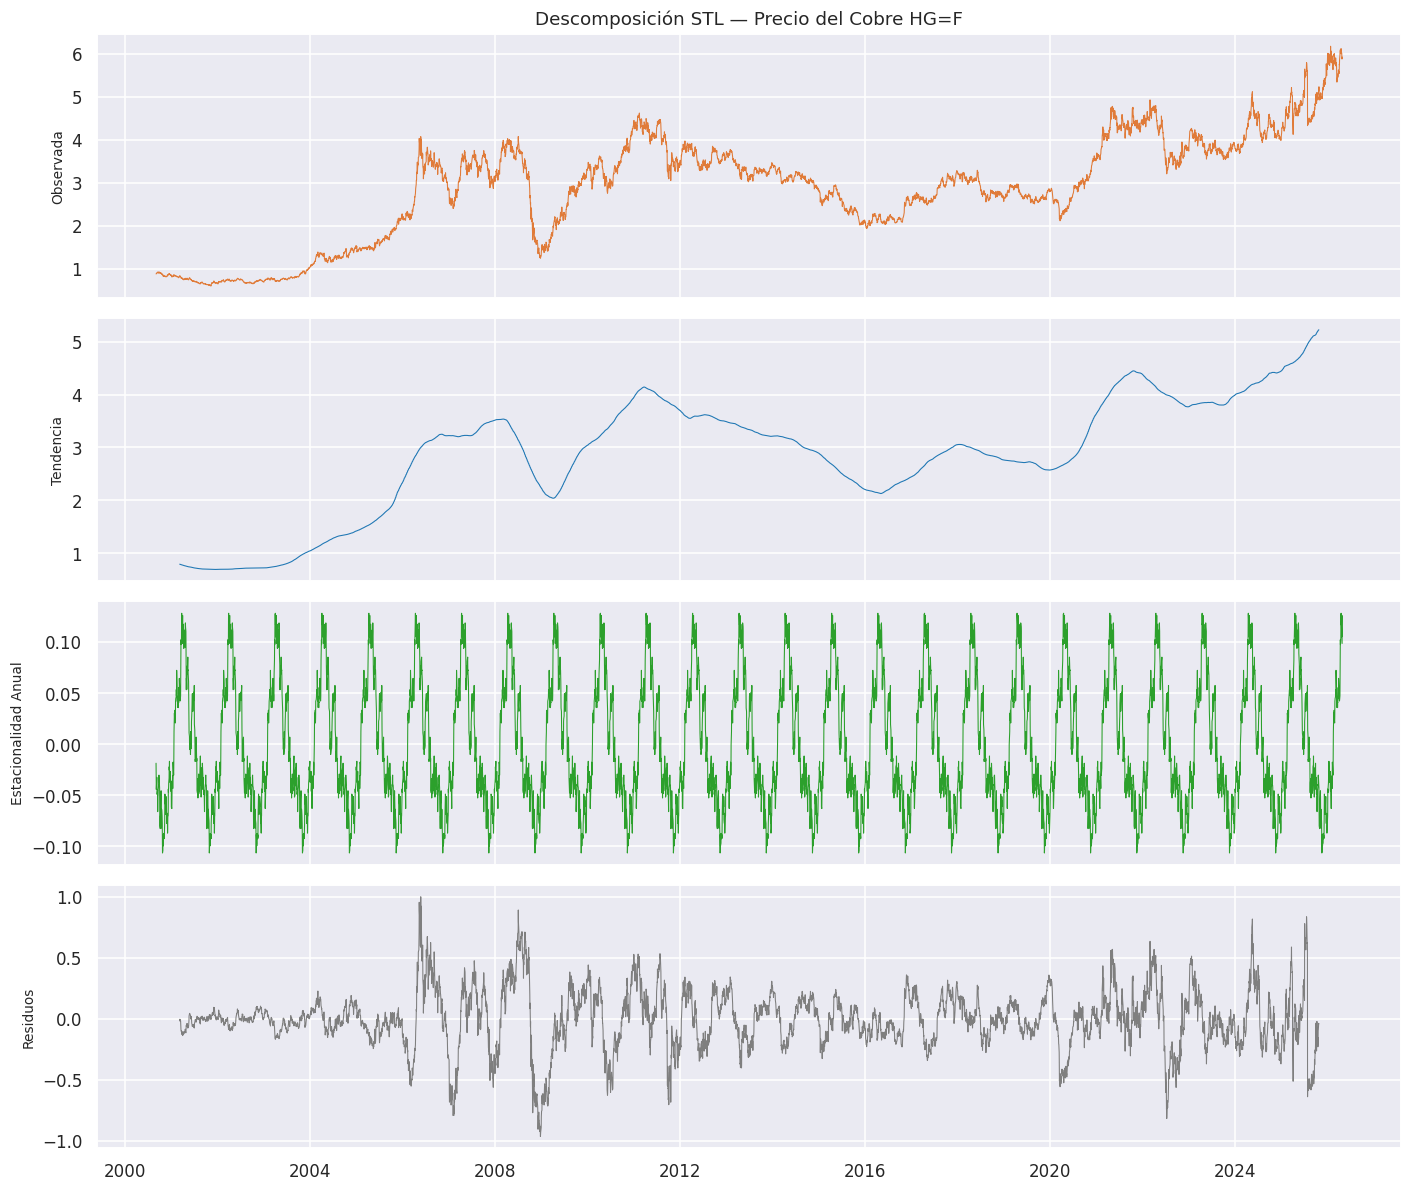

In [5]:
# ── Descomposición aditiva, periodo = 252 días hábiles (1 año bursátil) ───────
decomp = seasonal_decompose(df, model='additive', period=252)

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
pares = [
    (decomp.observed, 'Observada',          '#e07b39'),
    (decomp.trend,    'Tendencia',           '#1f77b4'),
    (decomp.seasonal, 'Estacionalidad Anual','#2ca02c'),
    (decomp.resid,    'Residuos',            '#7f7f7f'),
]
for ax, (comp, titulo, color) in zip(axes, pares):
    ax.plot(comp, color=color, linewidth=0.7)
    ax.set_ylabel(titulo, fontsize=9)

axes[0].set_title('Descomposición STL — Precio del Cobre HG=F', fontsize=12)
plt.tight_layout()
plt.savefig('output/02_descomposicion_stl.png', bbox_inches='tight')
plt.show()

## 5. Pruebas de Estacionariedad
| Prueba | H₀ | Rechazo H₀ significa... |
|---|---|---|
| **ADF** | Raíz unitaria presente | Serie **estacionaria** |
| **KPSS** | Serie estacionaria | Serie **no estacionaria** |

In [6]:
# ── Funciones reutilizables de diagnosis ───────────────────────────────────────
def test_adf(serie, nombre='Serie'):
    res = adfuller(serie.dropna(), autolag='AIC')
    est = res[1] < 0.05
    print(f'\n── ADF ({nombre}) ──  stat={res[0]:.4f}  p={res[1]:.4f}  lags={res[2]}')
    print(f'   → {"✅ ESTACIONARIA" if est else "❌ NO estacionaria"}')
    return est

def test_kpss(serie, nombre='Serie'):
    res = kpss(serie.dropna(), regression='c', nlags='auto')
    est = res[1] >= 0.05
    print(f'\n── KPSS ({nombre}) ── stat={res[0]:.4f}  p={res[1]:.4f}')
    print(f'   → {"✅ ESTACIONARIA" if est else "❌ NO estacionaria"}')
    return est

# ── Pruebas en niveles ─────────────────────────────────────────────────────────
print('='*55)
print('SERIE EN NIVELES (precios crudos)')
print('='*55)
test_adf(df, 'Niveles')
test_kpss(df, 'Niveles')

SERIE EN NIVELES (precios crudos)

── ADF (Niveles) ──  stat=-1.1637  p=0.6890  lags=21
   → ❌ NO estacionaria

── KPSS (Niveles) ── stat=6.6698  p=0.0100
   → ❌ NO estacionaria


/tmp/ipykernel_44849/3370194268.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(serie.dropna(), regression='c', nlags='auto')


np.False_

In [7]:
# ── Primera diferencia (d=1) ────────────────────────────────────────────────────
# Diferenciamos para eliminar la raíz unitaria
df_diff = df.diff().dropna()
df_diff.name = 'HG=F_diff1'

print('='*55)
print('SERIE DIFERENCIADA (d=1)')
print('='*55)
adf_ok  = test_adf(df_diff,  'Diferenciada d=1')
kpss_ok = test_kpss(df_diff, 'Diferenciada d=1')

print(f'\nVeredicto orden integración: d = {1 if adf_ok and kpss_ok else "?"}')

SERIE DIFERENCIADA (d=1)



── ADF (Diferenciada d=1) ──  stat=-17.7699  p=0.0000  lags=20
   → ✅ ESTACIONARIA

── KPSS (Diferenciada d=1) ── stat=0.0706  p=0.1000
   → ✅ ESTACIONARIA

Veredicto orden integración: d = 1


/tmp/ipykernel_44849/3370194268.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(serie.dropna(), regression='c', nlags='auto')


## 6. ACF / PACF — ¿Caminata Aleatoria?
Si la serie diferenciada es ruido blanco, los correlogramas no tendrán barras significativas. Eso equivale a ARIMA(0,1,0) = **Random Walk**.

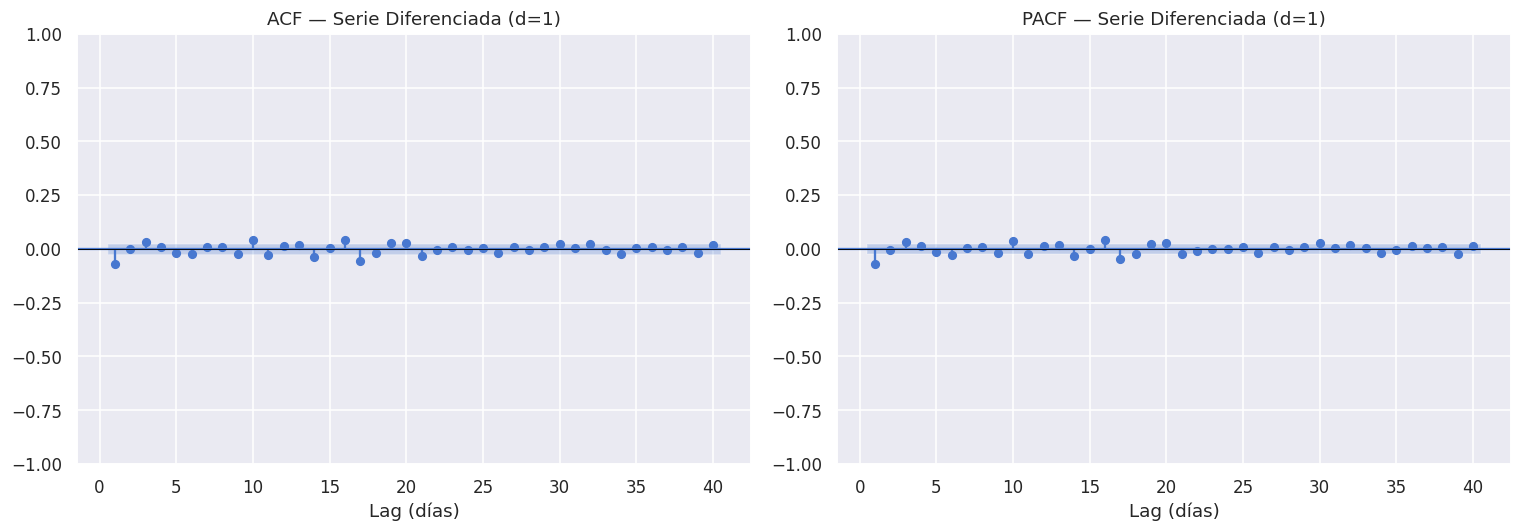

In [8]:
# ── Correlogramas de la serie diferenciada ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df_diff, lags=40, ax=axes[0], zero=False, alpha=0.05,
         title='ACF — Serie Diferenciada (d=1)')
plot_pacf(df_diff, lags=40, ax=axes[1], zero=False, alpha=0.05,
          method='ywm', title='PACF — Serie Diferenciada (d=1)')

for ax in axes:
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xlabel('Lag (días)')

plt.tight_layout()
plt.savefig('output/03_acf_pacf_diff.png', bbox_inches='tight')
plt.show()

## 7. Detección de Efectos ARCH
Aunque la **media** de los retornos no sea predecible, la **varianza** puede tener memoria. El test LM de Engle verifica autocorrelación en los retornos al cuadrado.

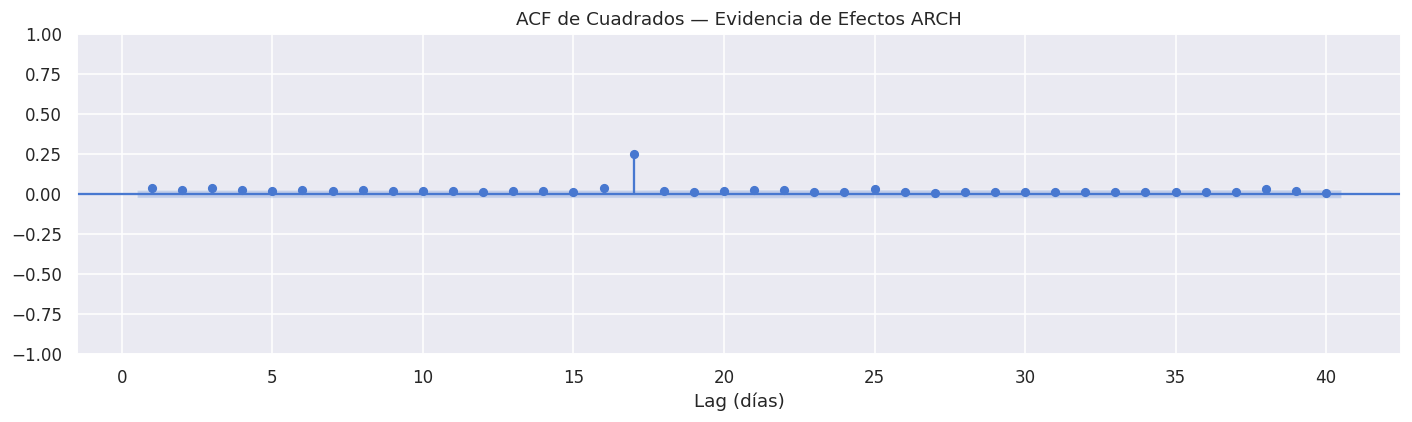


Test Engle LM-ARCH: estadístico=32.5531  p-valor=3.2371e-04
→ ✅ EFECTOS ARCH PRESENTES → GARCH justificado


In [9]:
# ── ACF de los cuadrados — visualiza clusters de volatilidad ───────────────────
fig, ax = plt.subplots(figsize=(13, 4))
plot_acf(df_diff**2, lags=40, ax=ax, zero=False, alpha=0.05,
         title='ACF de Cuadrados — Evidencia de Efectos ARCH')
ax.set_xlabel('Lag (días)')
plt.tight_layout()
plt.savefig('output/04_acf_cuadrados.png', bbox_inches='tight')
plt.show()

# ── Test de Engle — H0: no hay efectos ARCH ────────────────────────────────────
lm_stat, lm_pval, _, _ = het_arch(df_diff.values, nlags=10)
print(f'\nTest Engle LM-ARCH: estadístico={lm_stat:.4f}  p-valor={lm_pval:.4e}')
print('→ ✅ EFECTOS ARCH PRESENTES → GARCH justificado' if lm_pval < 0.05
      else '→ ❌ Sin efectos ARCH')

## 8. Retornos y Distribución

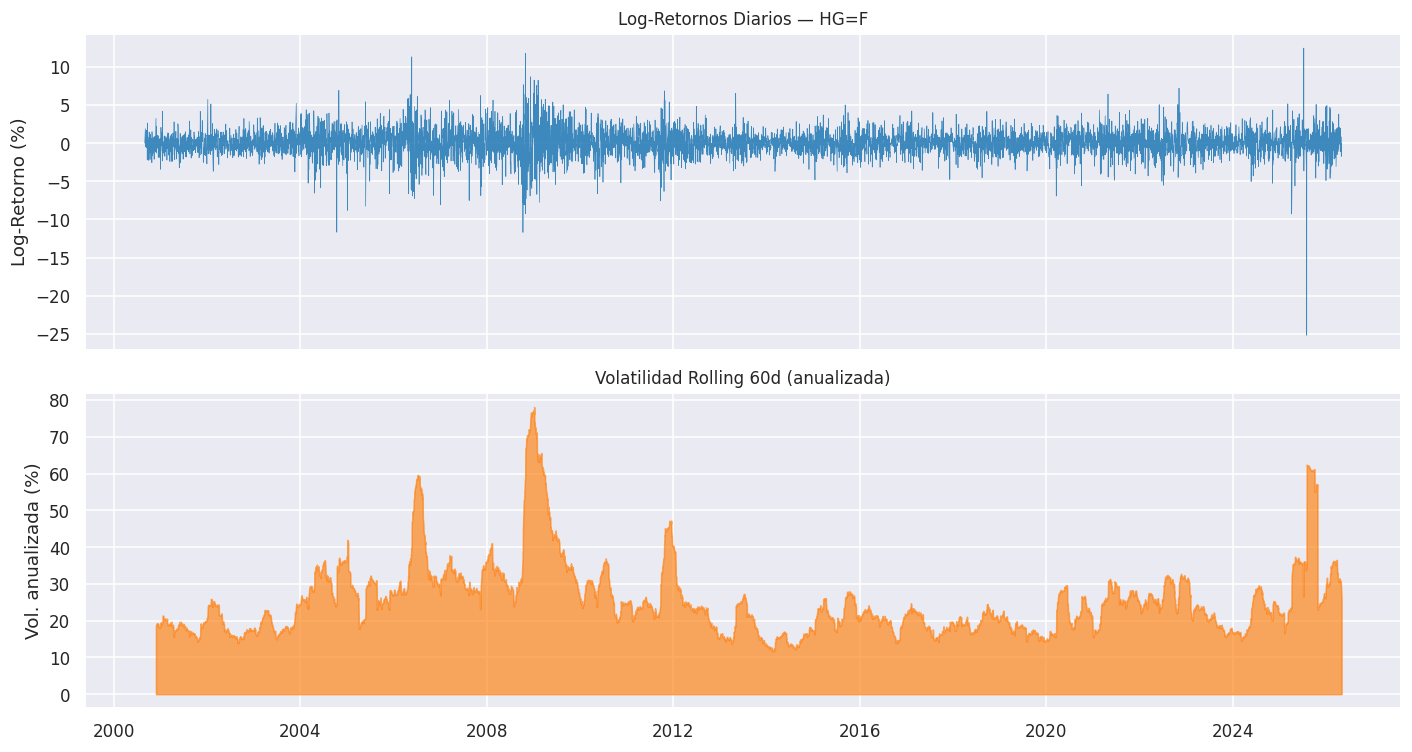

Volatilidad histórica anualizada (full sample): 27.34%


In [10]:
# ── Retornos logarítmicos (requeridos por GARCH) ───────────────────────────────
retornos_log = np.log(df / df.shift(1)).dropna() * 100  # en %
retornos_log.name = 'log_return_pct'

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(retornos_log, color='#1f77b4', linewidth=0.45, alpha=0.85)
axes[0].set_title('Log-Retornos Diarios — HG=F', fontsize=11)
axes[0].set_ylabel('Log-Retorno (%)')

# Volatilidad rolling 60 días para visualizar clusters
vol_roll = retornos_log.rolling(60).std() * np.sqrt(252)
axes[1].fill_between(vol_roll.index, vol_roll.values, alpha=0.65, color='#ff7f0e')
axes[1].set_title('Volatilidad Rolling 60d (anualizada)', fontsize=11)
axes[1].set_ylabel('Vol. anualizada (%)')

plt.tight_layout()
plt.savefig('output/05_retornos_volatilidad.png', bbox_inches='tight')
plt.show()

print(f'Volatilidad histórica anualizada (full sample): {retornos_log.std() * np.sqrt(252):.2f}%')

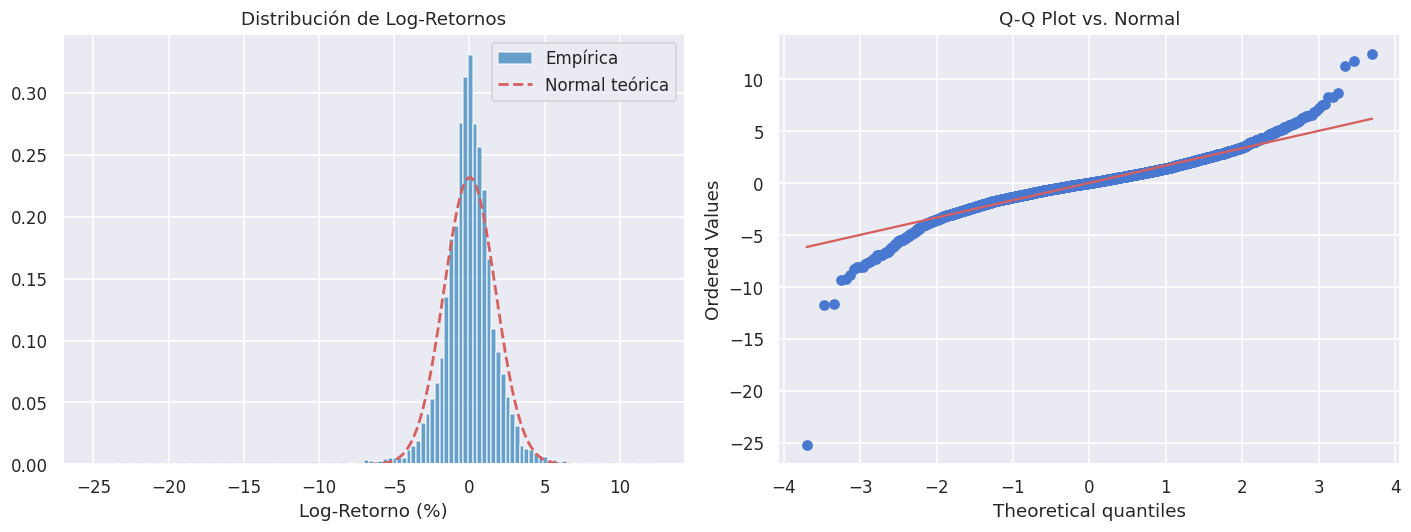

Jarque-Bera : 32,532.5  p=0.00e+00
Asimetría   : -0.6051
Curtosis exc: 10.9502
→ Colas pesadas confirmadas (leptocúrtica)


In [11]:
# ── Distribución empírica vs. Normal — colas pesadas ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(retornos_log, bins=120, density=True,
             color='#1f77b4', alpha=0.65, label='Empírica')
x = np.linspace(float(retornos_log.min()), float(retornos_log.max()), 300)
axes[0].plot(x, sp_stats.norm.pdf(x, retornos_log.mean(), retornos_log.std()),
             'r--', lw=1.8, label='Normal teórica')
axes[0].set_title('Distribución de Log-Retornos')
axes[0].set_xlabel('Log-Retorno (%)')
axes[0].legend()

sp_stats.probplot(retornos_log, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot vs. Normal')

plt.tight_layout()
plt.savefig('output/06_distribucion_retornos.png', bbox_inches='tight')
plt.show()

jb_stat, jb_pval = sp_stats.jarque_bera(retornos_log)
print(f'Jarque-Bera : {jb_stat:,.1f}  p={jb_pval:.2e}')
print(f'Asimetría   : {retornos_log.skew():.4f}')
print(f'Curtosis exc: {retornos_log.kurt():.4f}')
print('→ Colas pesadas confirmadas (leptocúrtica)' if jb_pval < 0.05 else '→ Compatible con Normal')

## 9. Exportar artefactos para Fase 2

In [12]:
# ── Guardar series limpias para uso en notebooks siguientes ────────────────────
df.to_csv('data/hg_close.csv', header=True)
retornos_log.to_csv('data/hg_log_returns.csv', header=True)

print('Artefactos exportados:')
print('  data/hg_close.csv       — Precios de cierre HG=F (1990-2026)')
print('  data/hg_log_returns.csv — Log-retornos diarios en % (input GARCH)')

Artefactos exportados:
  data/hg_close.csv       — Precios de cierre HG=F (1990-2026)
  data/hg_log_returns.csv — Log-retornos diarios en % (input GARCH)


## Conclusiones de la Fase 1

| Hallazgo | Resultado | Implicación para fases siguientes |
|---|---|---|
| **Tendencia** | Ascendente no lineal (superciclo 2003–2011, re-aceleración 2020+) | Los modelos de media deben manejar no linealidad |
| **Estacionariedad en niveles** | ADF p>0.05 + KPSS p<0.05 → **No estacionaria** | Necesaria diferenciación: **d=1** |
| **Estacionariedad d=1** | ADF p<0.001 + KPSS p>0.1 → **Estacionaria** | Una sola diferencia es suficiente |
| **ACF/PACF diferenciada** | Sin autocorrelación significativa | **Caminata Aleatoria** ARIMA(0,1,0) |
| **Efectos ARCH** | LM p<0.001 → Confirmados | **GARCH(1,1) obligatorio** para varianza |
| **Distribución** | Leptocúrtica, asimétrica (JB p<0.001) | VaR Normal subestimaría riesgo real |

**Diagnóstico final:** El precio del cobre sigue un proceso I(1) con heterocedasticidad condicional. El mercado es **eficiente en media** (dirección no predecible) pero **ineficiente en varianza** (volatilidad tiene memoria). El mayor valor práctico de este proyecto estará en la **Fase 4 (GARCH)** para gestión de riesgo y cálculo de VaR.